In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from skforecast.recursive import ForecasterRecursive
from sklearn.ensemble import RandomForestRegressor
from skforecast.model_selection import TimeSeriesFold, grid_search_forecaster, backtesting_forecaster
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

C:\Users\Hatim.Hakeel\source\repos\Jupyter\LabsTest\jltenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("Sales prediction")

Sales prediction


In [3]:
# CSV file TransactionDate values in 1/14/2013 format

fpath = 'C:\\Users\\Hatim.Hakeel\\Downloads\\WideWorldImporters_ToysAndMachines.csv'
df = pd.read_csv(fpath, parse_dates=['TransactionDate'], date_format='%m/%d/%Y')

In [4]:
print(df)

       CustomerTransactionID  CustomerID  TransactionTypeID  InvoiceID  \
0                          7           1                  1          3   
1                         11           1                  1          4   
2                         31           1                  1          9   
3                         34           1                  1         10   
4                         66           1                  1         21   
...                      ...         ...                ...        ...   
22311                 336159           1                  1      70489   
22312                 336189           1                  1      70497   
22313                 336199           1                  1      70499   
22314                 336208           1                  1      70501   
22315                 336246           1                  1      70509   

       PaymentMethodID TransactionDate  AmountExcludingTax  TaxAmount  \
0                  NaN      2013-01-01

In [5]:
print(df.dtypes)

CustomerTransactionID             int64
CustomerID                        int64
TransactionTypeID                 int64
InvoiceID                         int64
PaymentMethodID                 float64
TransactionDate          datetime64[ns]
AmountExcludingTax              float64
TaxAmount                       float64
TransactionAmount               float64
OutstandingBalance              float64
FinalizationDate                 object
IsFinalized                       int64
LastEditedBy                      int64
LastEditedWhen                   object
dtype: object


In [6]:
df[['TrxTotal']] = df.groupby('TransactionDate').agg({'TransactionAmount': 'cumsum'})
df = df.drop_duplicates(subset=['TransactionDate'], keep='last', ignore_index=True)

print(df)

      CustomerTransactionID  CustomerID  TransactionTypeID  InvoiceID  \
0                       103           1                  1         33   
1                       544           1                  1        127   
2                       875           1                  1        199   
3                      1159           1                  1        260   
4                      1357           1                  1        306   
...                     ...         ...                ...        ...   
1064                 334863           1                  1      70222   
1065                 335303           1                  1      70317   
1066                 335480           1                  1      70348   
1067                 335787           1                  1      70415   
1068                 336246           1                  1      70509   

      PaymentMethodID TransactionDate  AmountExcludingTax  TaxAmount  \
0                 NaN      2013-01-01              

In [7]:
print("TrxTotal min:{} max:{} mean:{} median:{} std:{}".format(df['TrxTotal'].min(), df['TrxTotal'].max(), df['TrxTotal'].mean(), 
                                                              df['TrxTotal'].median(), df['TrxTotal'].std()))

TrxTotal min:3633.2500000000005 max:169387.41999999998 mean:58610.16142188962 median:56089.65 std:27257.13487160271


[ 27  96 130 150 170 146 131  95  55  37  20   5   4   2   1] [  3633.25   14683.528  25733.806  36784.084  47834.362  58884.64
  69934.918  80985.196  92035.474 103085.752 114136.03  125186.308
 136236.586 147286.864 158337.142 169387.42 ]


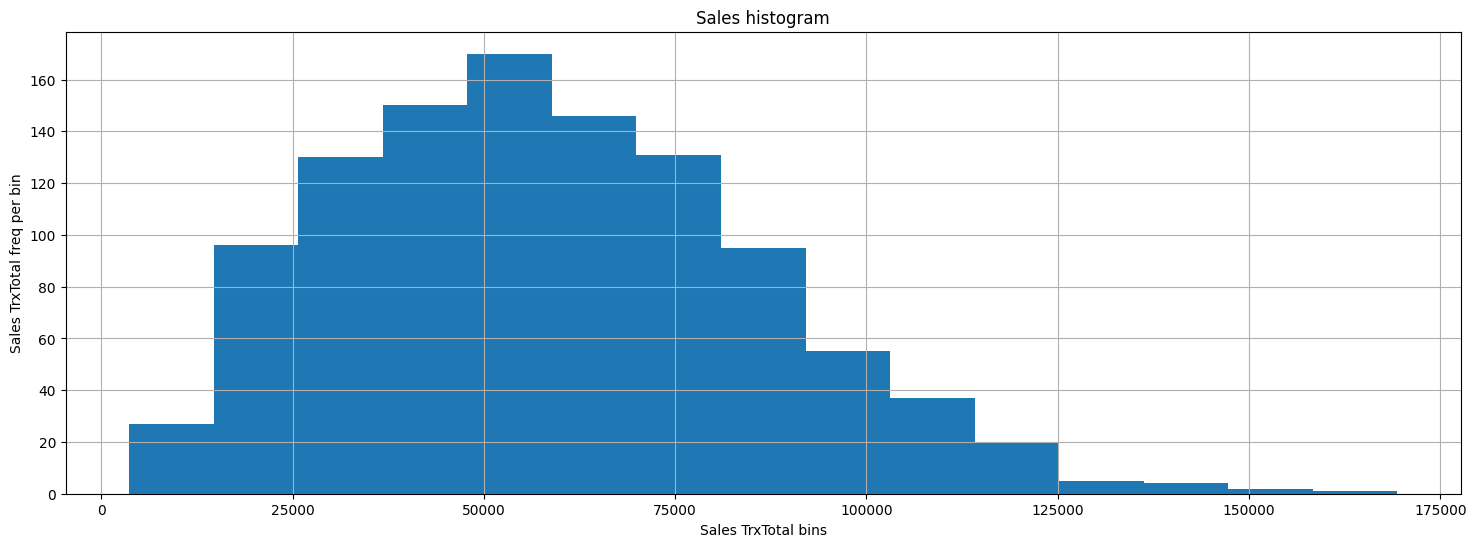

In [8]:
plt.figure(figsize = (18,6))

count, bins = np.histogram(df['TrxTotal'], bins=15)
print("{} {}".format(count, bins))
#plt.stairs(count, bins)
#plt.hist(bins[:-1], bins, weights=count)

plt.hist(df['TrxTotal'], bins=15)
plt.title('Sales histogram')
plt.xlabel('Sales TrxTotal bins')
plt.ylabel('Sales TrxTotal freq per bin')
plt.grid(axis='both')
#plt.show()

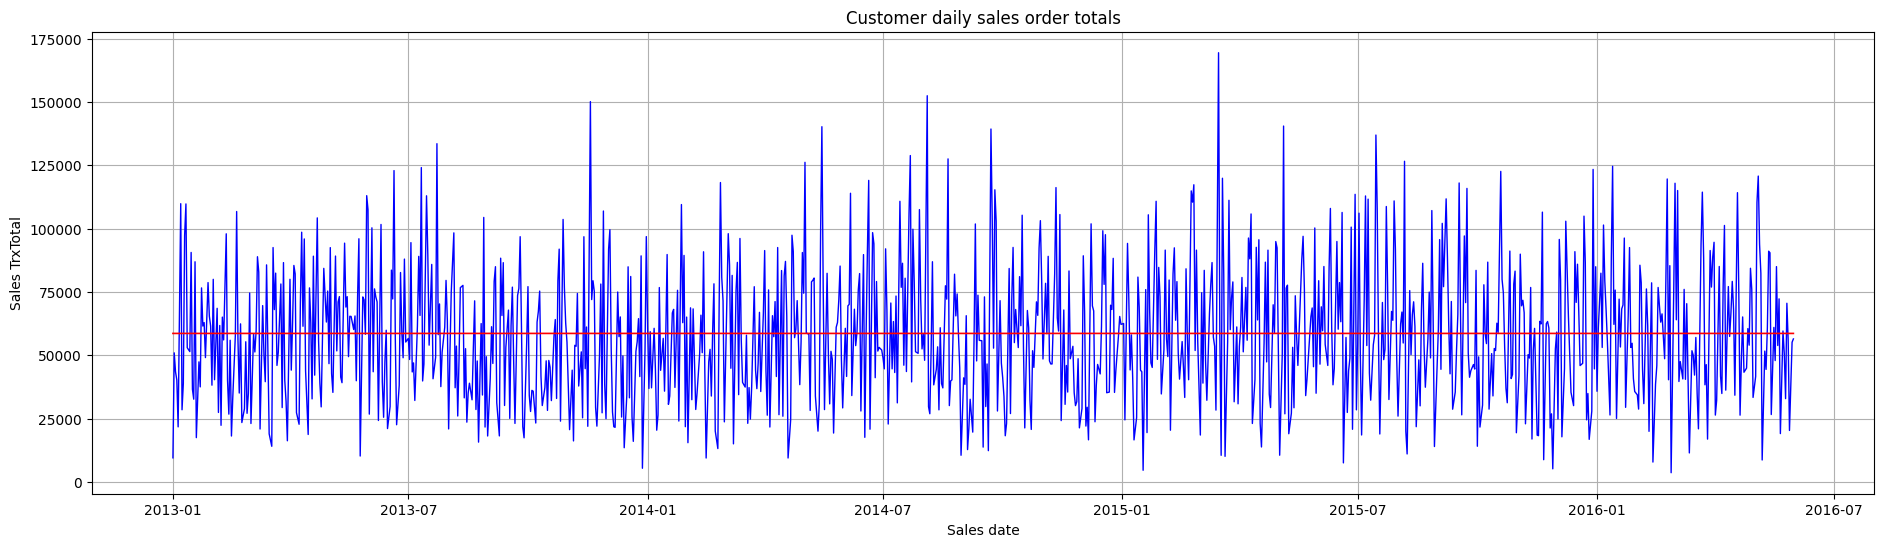

In [9]:
plt.close('all')

plt.figure(figsize = (23,6))

plt.plot(df['TransactionDate'], df['TrxTotal'], linestyle='-', color='blue', linewidth=1)
plt.title('Customer daily sales order totals')
plt.xlabel('Sales date')
plt.ylabel('Sales TrxTotal')
plt.grid(axis='both')

plt.plot(df['TransactionDate'], np.full(len(df), df['TrxTotal'].mean()), linestyle='-', 
         color='red', linewidth=1.2)
#plt.show()

In [10]:
dfts = df.loc[:, ['TransactionDate', 'TrxTotal']]

In [11]:
print(dfts.dtypes)

TransactionDate    datetime64[ns]
TrxTotal                  float64
dtype: object


In [12]:
dfts.set_index('TransactionDate', inplace=True)

In [13]:
print(dfts)

                 TrxTotal
TransactionDate          
2013-01-01        9513.49
2013-01-02       50940.86
2013-01-03       43437.29
2013-01-04       40219.65
2013-01-05       21730.00
...                   ...
2016-05-26       70512.35
2016-05-27       55819.67
2016-05-28       20310.38
2016-05-30       55119.07
2016-05-31       56435.84

[1069 rows x 1 columns]


In [14]:
dftsintp = dfts.asfreq('D', fill_value=df['TrxTotal'].mean())
dftsintp = dftsintp.sort_index()

print(dftsintp)

                     TrxTotal
TransactionDate              
2013-01-01        9513.490000
2013-01-02       50940.860000
2013-01-03       43437.290000
2013-01-04       40219.650000
2013-01-05       21730.000000
...                       ...
2016-05-27       55819.670000
2016-05-28       20310.380000
2016-05-29       58610.161422
2016-05-30       55119.070000
2016-05-31       56435.840000

[1247 rows x 1 columns]


In [15]:
dftsintp_train = dftsintp.loc['2013-01-01': '2015-06-30']
dftsintp_test = dftsintp.loc['2015-07-01': '2016-05-31']

print(dftsintp_train)
print(dftsintp_test)

                      TrxTotal
TransactionDate               
2013-01-01         9513.490000
2013-01-02        50940.860000
2013-01-03        43437.290000
2013-01-04        40219.650000
2013-01-05        21730.000000
...                        ...
2015-06-26       100561.920000
2015-06-27        20777.400000
2015-06-28        58610.161422
2015-06-29       113495.810000
2015-06-30        28445.480000

[911 rows x 1 columns]
                      TrxTotal
TransactionDate               
2015-07-01        54380.390000
2015-07-02       106067.460000
2015-07-03        50656.060000
2015-07-04        18529.610000
2015-07-05        58610.161422
...                        ...
2016-05-27        55819.670000
2016-05-28        20310.380000
2016-05-29        58610.161422
2016-05-30        55119.070000
2016-05-31        56435.840000

[336 rows x 1 columns]


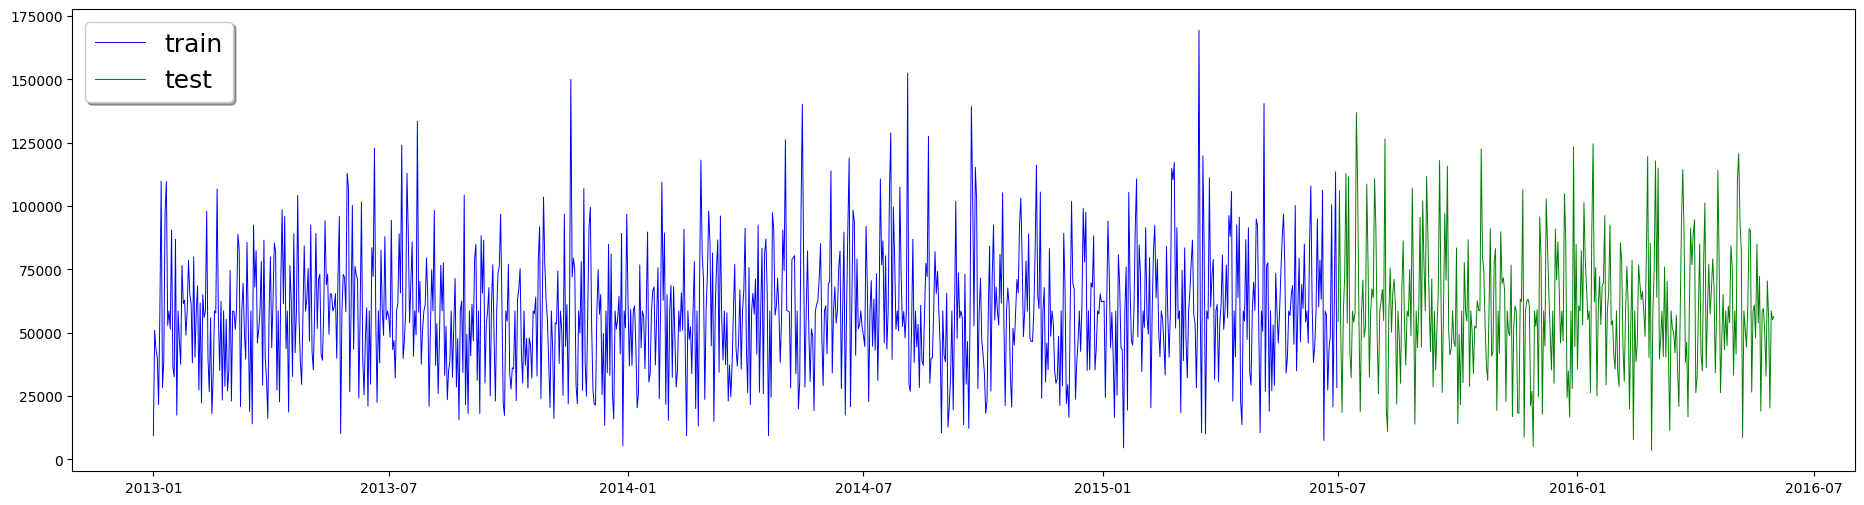

In [16]:
plt.close('all')

plt.figure(figsize = (23,6))
#plt.title('Customer daily sales order totals for 2015-2016')
#plt.xlabel('Sales date')
#plt.ylabel('Sales TrxTotal')
plt.plot(dftsintp_train, label='train', color='blue', linewidth=0.7)
plt.plot(dftsintp_test, label='test', color='green', linewidth=0.7)
plt.legend(loc='upper left', fontsize=18, frameon=True, shadow=True)
#plt.show()

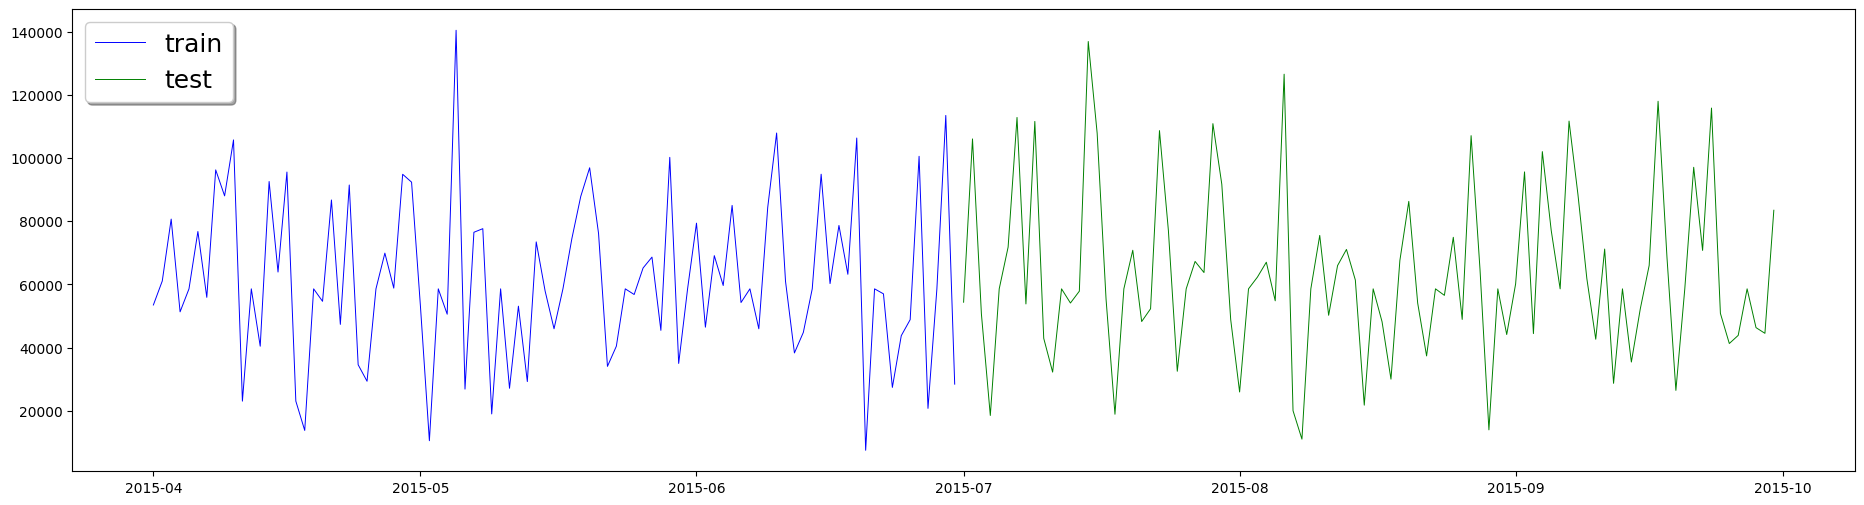

In [20]:
plt.close('all')

plt.figure(figsize = (23,6))
#plt.title('Customer daily sales order totals for 2015-2016')
#plt.xlabel('Sales date')
#plt.ylabel('Sales TrxTotal')
plt.plot(dftsintp_train.loc['2015-04-01':'2015-06-30'], label='train', color='blue', linewidth=0.7)
plt.plot(dftsintp_test.loc['2015-07-01':'2015-09-30'], label='test', color='green', linewidth=0.7)
plt.legend(loc='upper left', fontsize=18, frameon=True, shadow=True)
#plt.show()

In [22]:
forecaster = ForecasterRecursive(regressor=RandomForestRegressor(random_state=123, verbose=0), lags=30)  #180 #120
forecaster.fit(y=dftsintp_train['TrxTotal'])
forecaster

=================== 
ForecasterRecursive 
=================== 
Regressor: RandomForestRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30] 
Window features: None 
Window size: 30 
Series name: TrxTotal 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2013-01-01 00:00:00'), Timestamp('2015-06-30 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100,
    'n_jobs': None, 'oob_score': False, 'random_state': 123, 'verbose': 0,
    'warm_start': False} 
fit_kwargs: {} 
Creation date: 2025-10-24 23:47:29 
Last fit date: 2025-10-24 23:47:30 
Skforecast version: 0.18.0 
Python version: 3.9.13 
Forecaster id: None

In [23]:
predictions = forecaster.predict(steps = 31)  #249 #60
predictions.head(10)

2015-07-01    68696.768828
2015-07-02    59826.479556
2015-07-03    57349.487600
2015-07-04    39091.566900
2015-07-05    59667.519938
2015-07-06    63147.703643
2015-07-07    70515.970414
2015-07-08    59531.388228
2015-07-09    62508.844442
2015-07-10    57268.620100
Freq: D, Name: pred, dtype: float64

In [31]:
results = grid_search_forecaster(forecaster = forecaster, y = dftsintp_train['TrxTotal'], 
                                 cv = TimeSeriesFold(steps=31, initial_train_size=int(len(dftsintp_train) * 0.5),
                                                    refit=False, fixed_train_size=False),
                                lags_grid=[30], param_grid={'n_estimators': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 50, 
                                                                             100, 150, 200, 250], 
                                                          'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]},
                                metric='mean_squared_error', return_best=True, n_jobs='auto', verbose=False)

lags grid: 100%|██████████| 1/1 [01:16<00:00, 76.30s/it]      


`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30] 
  Parameters: {'max_depth': 10, 'n_estimators': 50}
  Backtesting metric: 617461424.4962538


In [32]:
#pd.set_option('display.max_rows', None)
results

,lags,lags_label,params,mean_squared_error,max_depth,n_estimators
0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 10, 'n_estimators': 50}",6.174614e+08,10,50
1,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 10, 'n_estimators': 100}",6.196154e+08,10,100
2,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 8, 'n_estimators': 15}",6.207209e+08,8,15
3,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 8, 'n_estimators': 50}",6.208681e+08,8,50
4,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 9, 'n_estimators': 100}",6.212538e+08,9,100
5,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 8, 'n_estimators': 200}",6.225098e+08,8,200
6,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 8, 'n_estimators': 100}",6.227935e+08,8,100
7,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 9, 'n_estimators': 150}",6.228850e+08,9,150
8,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 7, 'n_estimators': 15}",6.229073e+08,7,15
9,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 8, 'n_estimators': 150}",6.231498e+08,8,150


In [33]:
forecaster = ForecasterRecursive(regressor=RandomForestRegressor(random_state=123, verbose=0, 
                                                                 max_depth=10, n_estimators=50), lags=30)
forecaster.fit(y=dftsintp_train['TrxTotal'])
forecaster

=================== 
ForecasterRecursive 
=================== 
Regressor: RandomForestRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30] 
Window features: None 
Window size: 30 
Series name: TrxTotal 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2013-01-01 00:00:00'), Timestamp('2015-06-30 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    10, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 50,
    'n_jobs': None, 'oob_score': False, 'random_state': 123, 'verbose': 0,
    'warm_start': False} 
fit_kwargs: {} 
Creation date: 2025-10-24 23:55:44 
Last fit date: 2025-10-24 23:55:45 
Skforecast version: 0.18.0 
Python version: 3.9.13 
Forecaster id: None

In [34]:
predictions = forecaster.predict(steps = 31)
predictions.head(10)

2015-07-01    71090.790435
2015-07-02    60082.024941
2015-07-03    58619.049911
2015-07-04    41423.601261
2015-07-05    61050.172471
2015-07-06    62449.323194
2015-07-07    71081.576469
2015-07-08    58018.377365
2015-07-09    64026.376524
2015-07-10    58024.871270
Freq: D, Name: pred, dtype: float64

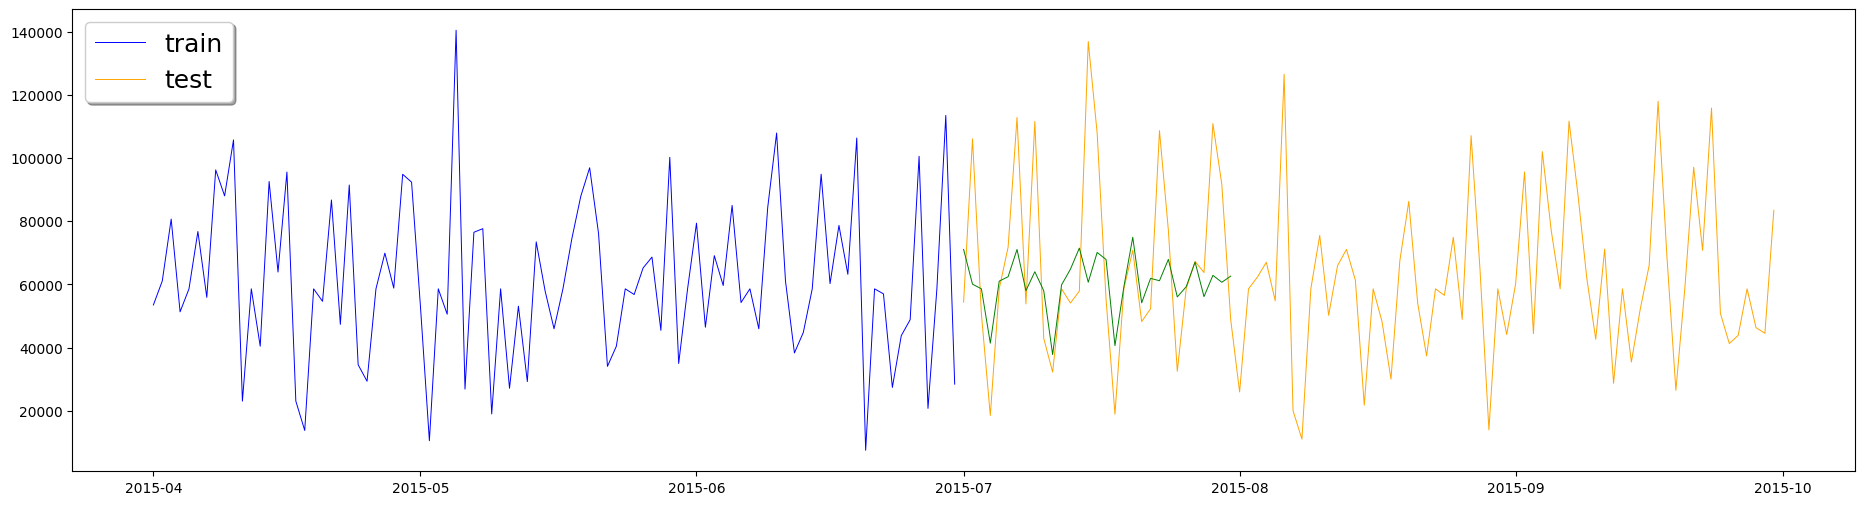

In [35]:
plt.close('all')

plt.figure(figsize = (23,6))
#plt.title('Customer daily sales order totals for 2015-2016')
#plt.xlabel('Sales date')
#plt.ylabel('Sales TrxTotal')
plt.plot(dftsintp_train.loc['2015-04-01':'2015-06-30'], label='train', color='blue', linewidth=0.7)
plt.plot(dftsintp_test.loc['2015-07-01':'2015-09-30'], label='test', color='orange', linewidth=0.7)
plt.plot(predictions, color='green', linewidth=0.7)
plt.legend(loc='upper left', fontsize=18, frameon=True, shadow=True)
#plt.show()